# Tutorial 08 — Spectral polarimetry of a rain + ice mixture

Rain falls at ~5 m/s; unrimed aggregates at ~1 m/s. In mixed-phase
volumes the two populations show up as distinct *modes* in the
Doppler spectrum. The magic of spectral polarimetry is that each
velocity bin carries its own sZ_dr(v), sρ_hv(v), and sδ_hv(v), so
the two components can be diagnosed separately even when the bulk
observables average them together.

`HydroMix` + `SpectralIntegrator` handle this natively: each
component gets its own fall-speed and turbulence model, and the
integrator sums per-component spectra on a shared velocity grid.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from rustmatrix import (HydroMix, MixtureComponent, Scatterer,
                         SpectralIntegrator, radar, spectra)
from rustmatrix.psd import ExponentialPSD, GammaPSD, PSDIntegrator
from rustmatrix.refractive import m_w_10C, mi
from rustmatrix.tmatrix_aux import (K_w_sqr, dsr_thurai_2007,
                                      geom_vert_back, geom_vert_forw,
                                      wl_X)


## Build rain and low-density ice scatterers


In [2]:
def build_rain():
    s = Scatterer(wavelength=wl_X, m=m_w_10C[wl_X],
                  Kw_sqr=K_w_sqr[wl_X], ddelt=1e-4, ndgs=2)
    integ = PSDIntegrator()
    integ.D_max = 6.0; integ.num_points = 64
    integ.axis_ratio_func = lambda D: 1.0 / dsr_thurai_2007(D)
    integ.geometries = (geom_vert_back, geom_vert_forw)
    s.psd_integrator = integ
    s.psd_integrator.init_scatter_table(s)
    s.psd = GammaPSD(D0=1.5, Nw=8e3, mu=4, D_max=6.0)
    return s

def build_ice():
    s = Scatterer(wavelength=wl_X, m=mi(wl_X, 0.2),
                  Kw_sqr=K_w_sqr[wl_X], axis_ratio=0.6,
                  ddelt=1e-4, ndgs=2)
    integ = PSDIntegrator()
    integ.D_max = 8.0; integ.num_points = 64
    integ.geometries = (geom_vert_back, geom_vert_forw)
    s.psd_integrator = integ
    s.psd_integrator.init_scatter_table(s)
    s.psd = ExponentialPSD(N0=5e3, Lambda=2.0, D_max=8.0)
    return s

rain = build_rain(); ice = build_ice()


## Assemble the mixture and run the spectral integrator


In [3]:
mix = HydroMix([
    MixtureComponent(rain, rain.psd, 'rain'),
    MixtureComponent(ice,  ice.psd,  'ice'),
])

integ = SpectralIntegrator(
    mix,
    component_kinematics={
        'rain': (spectra.fall_speed.atlas_srivastava_sekhon_1973,
                 spectra.GaussianTurbulence(0.2)),
        'ice':  (spectra.fall_speed.locatelli_hobbs_1974_aggregates,
                 spectra.GaussianTurbulence(0.2)),
    },
    v_min=-1.0, v_max=12.0, n_bins=1024,
    geometry_backscatter=geom_vert_back,
    geometry_forward=geom_vert_forw,
)
res = integ.run()

ice_mask = res.v < 2.0
rain_mask = res.v > 2.0
v_ice  = res.v[ice_mask][np.argmax(res.sZ_h[ice_mask])]
v_rain = res.v[rain_mask][np.argmax(res.sZ_h[rain_mask])]
valley_mask = (res.v > v_ice) & (res.v < v_rain)
v_valley = res.v[valley_mask][np.argmin(res.sZ_h[valley_mask])]
print(f'ice-mode peak  : v = {v_ice:.2f} m/s')
print(f'rain-mode peak : v = {v_rain:.2f} m/s')
print(f'inter-mode valley: v = {v_valley:.2f} m/s')


ice-mode peak  : v = 1.11 m/s
rain-mode peak : v = 6.90 m/s
inter-mode valley: v = 2.02 m/s


## Plot the bimodal spectrum

`sZ_h(v)` shows the two modes clearly; the sZ_dr trace is flat at
vertical pointing (H and V are symmetric for axisymmetric particles
along the vertical axis), which is exactly the behaviour bulk Z_dr
has at that geometry.


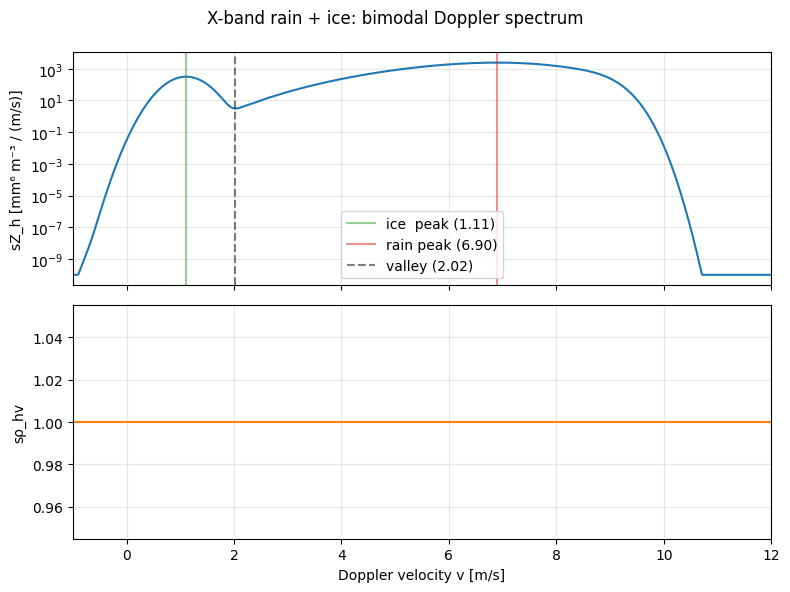

In [4]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
a1.semilogy(res.v, np.maximum(res.sZ_h, 1e-10), 'C0-')
a1.axvline(v_ice,   color='C2', alpha=0.5, label=f'ice  peak ({v_ice:.2f})')
a1.axvline(v_rain,  color='C3', alpha=0.5, label=f'rain peak ({v_rain:.2f})')
a1.axvline(v_valley, color='k', ls='--', alpha=0.5,
           label=f'valley ({v_valley:.2f})')
a1.set_ylabel('sZ_h [mm⁶ m⁻³ / (m/s)]')
a1.legend(); a1.grid(True, which='both', alpha=0.3)

a2.plot(res.v, res.srho_hv, 'C1-')
a2.set_ylabel('sρ_hv')
a2.set_xlabel('Doppler velocity v [m/s]')
a2.grid(True, alpha=0.3)
a2.set_xlim(-1, 12)
fig.suptitle('X-band rain + ice: bimodal Doppler spectrum')
fig.tight_layout();


## Bulk round-trip through collapse_to_bulk


In [5]:
bulk = res.collapse_to_bulk()
mix.set_geometry(geom_vert_back)
print(f'Z_h  bulk = {10*np.log10(radar.refl(mix)):.3f} dBZ   '
      f'spectrum = {10*np.log10(radar.refl(bulk)):.3f} dBZ')
print(f'Z_dr bulk = {10*np.log10(radar.Zdr(mix)):+.3f} dB    '
      f'spectrum = {10*np.log10(radar.Zdr(bulk)):+.3f} dB')
print(f'ρ_hv bulk = {radar.rho_hv(mix):.5f}       '
      f'spectrum = {radar.rho_hv(bulk):.5f}')


Z_h  bulk = 38.670 dBZ   spectrum = 38.670 dBZ
Z_dr bulk = +0.000 dB    spectrum = +0.000 dB
ρ_hv bulk = 1.00000       spectrum = 1.00000
